# 第4章: 言語解析

問題30から問題35までは、以下の文章`text`（太宰治の『走れメロス』の冒頭部分）に対して、言語解析を実施せよ。問題36から問題39までは、国家を説明した文書群（日本語版ウィキペディア記事から抽出したテキスト群）をコーパスとして、言語解析を実施せよ。

In [3]:
text = """
メロスは激怒した。
必ず、かの邪智暴虐の王を除かなければならぬと決意した。
メロスには政治がわからぬ。
メロスは、村の牧人である。
笛を吹き、羊と遊んで暮して来た。
けれども邪悪に対しては、人一倍に敏感であった。
"""

## 30. 動詞
文章`text`に含まれる動詞をすべて表示せよ。

In [4]:
!pip -q install -U ginza ja_ginza

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 72.0 MB/s eta 0:00:00


In [10]:
import spacy

nlp=spacy.load("ja_ginza")

doc=nlp(text)   #textをGiNZAで解析し、doc オブジェクトを生成
for token in doc:
    if token.pos_ == "VERB":    #token.pos_ は品詞タグ、token.text は単語の文字列そのもの
        print(token.text)

激怒
邪智
除か
なら
決意
わから
ある
吹き
遊ん
暮し
来
対し
あっ


GiNZA（ギンザ）とは

spaCyという自然言語処理フレームワークの上に構築された日本語解析ライブラリ。文を単語に分割し、各単語の品詞（名詞・動詞・助詞など）を判定する機能がある。

VERB（ヴァーブ）   動詞
NOUN（ナウン）  名詞
ADJ（アジェクティブ）    形容詞
ADP（アデポジション）    助詞
AUX（オックス）    助動詞

## 31. 動詞の原形
文章`text`に含まれる動詞と、その原形をすべて表示せよ。

In [11]:
import spacy

nlp = spacy.load(
    "ja_ginza",
    config={
        "components": {
            "compound_splitter": {
                "split_mode": "C"
            }
        }
    }
)

doc=nlp(text)
for token in doc:
    if token.pos_ == "VERB":
        print(f"{token.text}\t{token.lemma_}")

激怒	激怒
邪智	邪智
除か	除く
なら	なる
決意	決意
わから	わかる
ある	ある
吹き	吹く
遊ん	遊ぶ
暮し	暮す
来	来る
対し	対する
あっ	ある


## 32. 「AのB」
文章`text`において、2つの名詞が「の」で連結されている名詞句をすべて抽出せよ。

In [12]:
nlp=spacy.load("ja_ginza")
doc=nlp(text)   #textをGiNZAで解析し、doc オブジェクトを生成

for i in range(1,len(doc)-1):   #iは単語の位置。最初の単語には前の部分がなく、一番後ろは後ろの部分がないので範囲から外す。
    before = doc[i-1]
    current = doc[i]
    after = doc[i+1]

    if(
        before.pos_ == "NOUN"   #前の単語が名詞
        and current.text == "の"    #現在の単語が「の」
        and current.pos_ == "ADP"   #「の」が助詞として使われている
        and after.pos_ == "NOUN"
    ):

        print(f"{before.text}{current.text}{after.text}")

暴虐の王
村の牧人


## 33. 係り受け解析

文章`text`に係り受け解析を適用し、係り元と係り先のトークン（形態素や文節などの単位）をタブ区切り形式ですべて抽出せよ。

In [13]:
import spacy

nlp=spacy.load("ja_ginza")  #日本語の解析モデルを読み込んでnlpという変数に入れる
doc=nlp(text)

for token in doc:
    print(token.text + '\t' + token.head.text)


	メロス
メロス	激怒
は	メロス
激怒	激怒
し	激怒
た	激怒
。	激怒

	

必ず	除か
、	必ず
かの	暴虐
邪智	暴虐
暴虐	王
の	暴虐
王	除か
を	王
除か	決意
なけれ	除か
ば	なけれ
なら	なけれ
ぬ	なけれ
と	除か
決意	決意
し	決意
た	決意
。	決意

	メロス
メロス	わから
に	メロス
は	メロス
政治	わから
が	政治
わから	わから
ぬ	わから
。	わから

	メロス
メロス	牧人
は	メロス
、	メロス
村	牧人
の	村
牧人	牧人
で	牧人
ある	で
。	牧人

	笛
笛	吹き
を	笛
吹き	暮し
、	吹き
羊	遊ん
と	羊
遊ん	暮し
で	遊ん
暮し	暮し
て	暮し
来	て
た	暮し
。	暮し

	邪悪
けれど	

も	

邪悪	敏感
に	邪悪
対し	に
ては	に
、	邪悪
人	倍
一	倍
倍	敏感
に	倍
敏感	敏感
で	敏感
あっ	で
た	敏感
。	敏感

	



## 34. 主述の関係
文章`text`において、「メロス」が主語であるときの述語を抽出せよ。

In [14]:
import spacy

nlp=spacy.load("ja_ginza")
doc=nlp(text)

for token in doc:
    if token.text == 'メロス' and token.dep_ == "nsubj":
        print(token.head.text)

激怒
牧人


## 35. 係り受け木
「メロスは激怒した。」の係り受け木を可視化せよ。

In [17]:
import spacy
from spacy import displacy

nlp=spacy.load("ja_ginza")
doc=nlp("メロスは激怒した。")

displacy.render(doc,style="dep",jupyter=True)

## 36. 単語の出現頻度

問題36から39までは、Wikipediaの記事を以下のフォーマットで書き出したファイル[jawiki-country.json.gz](/data/jawiki-country.json.gz)をコーパスと見なし、統計的な分析を行う。

* 1行に1記事の情報がJSON形式で格納される
* 各行には記事名が"title"キーに、記事本文が"text"キーの辞書オブジェクトに格納され、そのオブジェクトがJSON形式で書き出される
* ファイル全体はgzipで圧縮される

まず、第3章の処理内容を参考に、Wikipedia記事からマークアップを除去し、各記事のテキストを抽出せよ。そして、コーパスにおける単語（形態素）の出現頻度を求め、出現頻度の高い20語とその出現頻度を表示せよ。

In [3]:
def clean_value(value):
    #強調表現除去
    value=re.sub(r"'{2,}","",value)

    #内部リンク除去
    value=re.sub(r'\[\[(?:[^|\]]+\|)?([^\]]+)\]\]',r'\1',value)

    #<ref>タグ除去
    value=re.sub(r'\<ref\b[^>]*>.*?</ref\s*>', '', value)   #\b　単語の境目を表す。→refrencesと誤認しない
    value=re.sub(r'\<ref\b[^>]*/>','',value)

    #改行・referenceタグ除去
    value=re.sub(r'<br\s*/?>','\n',value)     #\s*でスペース一個分以上。→属性は消さない
    value=re.sub(r'<references\s*/>','',value)

    #{{lang|・・・|・・・}} 言語テキストのみにする
    value=re.sub(r'\{\{lang\|[^|}]+\|([^}]+)\}\}',r'\1',value)  #+は1文字以上の繰り返し

    #{{仮リンク|日本語名|en|英語名}} → 日本語名
    value=re.sub(r'\{\{仮リンク\|([^|}]+).*?\}\}',r'\1',value)

    #{{cneter|内容}}　→ 内容
    value=re.sub(r'\{\{center\|([^}]+)\}\}',r'\1',value)

    #{{・・・}}
    value=re.sub(r'\{\{[^}]+\}\}','',value)

    #ファイルリンクをファイル名だけのこす
    value=re.sub(r'\[\[ファイル:([^|]]+).*?\]\]',r'\1',value)

    return value.strip()


In [28]:
import json
import gzip
import re
import spacy
from collections import Counter

nlp = spacy.load("ja_ginza")
word_counts = Counter()

with gzip.open('jawiki-country.json.gz', 'rt', encoding='utf-8') as f:
    for line in f:
        article = json.loads(line)
        #全文にしたら実行時間が長すぎたのでタイトルがイギリスのものに絞った
        if article['title'] == 'イギリス':
            cleaned_text = clean_value(article['text'])
            for sent in cleaned_text.split('。'):
                doc = nlp(sent)
                for token in doc:              # ← for token が抜けていた
                    word_counts[token.text] += 1
            break

for word, counts in word_counts.most_common(20):
    print(f"{word}\t{counts}")

、	764
の	705
に	478
は	449
|	441
=	435
が	358
で	350
を	310

	301
て	275
と	268
た	244
し	237
・	235
年	170


	157
イギリス	156
ある	137
*	107


## 37. 名詞の出現頻度
コーパスにおける名詞の出現頻度を求め、出現頻度の高い20語とその出現頻度を表示せよ。

In [4]:
import json
import gzip
import re
import spacy
from collections import Counter

nlp = spacy.load("ja_ginza")
word_counts = Counter()

with gzip.open("jawiki-country.json.gz", 'rt', encoding="utf-8") as f:
    for line in f:
        article = json.loads(line)
        if article['title'] == 'イギリス':
            cleaned_text = clean_value(article['text'])
            for sent in cleaned_text.split('。'):
                doc = nlp(sent)
                for token in doc:
                    if token.pos_ == "NOUN":
                        word_counts[token.text] += 1
            break

for word, counts in word_counts.most_common(20):
    print(f"{word}\t{counts}")

年	170
f	54
世界	52
%	51
人	45
王国	41


	39
北	35
月	34
"	34
こと	33
連合	29
第	28
日	27
国	27
位	26
世紀	25
px	24
つ	23
地域	23


## 38. TF・IDF
日本に関する記事における名詞のTF・IDFスコアを求め、TF・IDFスコア上位20語とそのTF, IDF, TF・IDFを表示せよ。

In [13]:
import json
import re
import gzip
import spacy
from collections import Counter

nlp=spacy.load("ja_ginza")
all_docs = {}   #記事から名詞を抽出{タイトル：[名詞リスト]}

with gzip.open("jawiki-country.json.gz", "rt", encoding="utf-8") as f:
    for line in f:
        article=json.loads(line)
        if article['title'] == '日本':
            nouns=[]
            cleaned_text=clean_value(article['text'])
            for sent in cleaned_text.split("。"):
                doc=nlp(sent)
                for token in doc:
                    if token.pos_ == "NOUN":
                        nouns.append(token.text)
                all_docs[article['title']]=nouns

# ② TFの計算（日本の記事）
japan_nouns = all_docs['日本']  #日本の記事から抽出した名詞リストを取り出す
tf_counter = Counter(japan_nouns)   #各単語の出現回数を調べる
total = len(japan_nouns)        #単語の総数を求める
tf = {}
for word, count in tf_counter.items():
    tf[word]=count/total    #tf_counter.items() は Counter の中身を (単語, 出現回数) のペアで1つずつ取り出します。
#各単語について「出現回数 ÷ 総数」を計算している。（その記事内での単語の出現割合を表す。）

# ③ IDFの計算（全記事）
N = len(all_docs)   #全記事数
idf = {}
for word in tf:
    #日本の記事に登場した各単語について、全記事のうちその単語を含む記事が何件あるか（DF）
    df=0
    for nouns in all_docs.values():
        if word in nouns:
            df+=1
    idf[word] = math.log(N / df)    #math.log(N / df) でIDFを計算する。全記事に登場する単語ほど df が大きく N/df が1に近づくため、log の値が0に近づく。

# ④ TF・IDFの計算と表示
tfidf = {word: tf[word] * idf[word] for word in tf}
top20 = sorted(tfidf.items(), key=lambda x: x[1], reverse=True)[:20]

print(f"{'単語':<15} {'TF':<10} {'IDF':<10} {'TF-IDF':<10}")
print('-' * 45)
for word, score in top20:
    print(f"{word:<15} {tf[word]:<10.4f} {idf[word]:<10.4f} {score:<10.4f}")


単語              TF         IDF        TF-IDF    
---------------------------------------------
Wikipedia       0.0007     0.0000     0.0000    
検証              0.0002     0.0000     0.0000    
可能性             0.0007     0.0000     0.0000    
出典              0.0004     0.0000     0.0000    
編集              0.0001     0.0000     0.0000    
こと              0.0092     0.0000     0.0000    
記述              0.0007     0.0000     0.0000    
文句              0.0001     0.0000     0.0000    
記事              0.0003     0.0000     0.0000    
情報源             0.0005     0.0000     0.0000    
内容              0.0002     0.0000     0.0000    
詳細              0.0005     0.0000     0.0000    
方針              0.0004     0.0000     0.0000    
https           0.0010     0.0000     0.0000    
D               0.0001     0.0000     0.0000    
分野              0.0012     0.0000     0.0000    
書き下ろし           0.0001     0.0000     0.0000    
教科書             0.0004     0.0000     0.0000    
著者              0.0001 

TF（Term Frequency）：ある記事の中でその単語が何回出てくるか（その記事での出現頻度）

IDF（Inverse Document Frequency）：全記事のうち何記事に登場するか（多くの記事に出る単語ほど低い値）
TF・IDF = TF × IDF：その記事に多く出て、かつ他の記事では珍しい単語ほど高スコア

In [14]:
import json
import gzip
import re
import math
import spacy
from collections import Counter

nlp = spacy.load("ja_ginza")

# ① 全記事から名詞を抽出
all_docs = {}   # {タイトル: [名詞リスト]}

with gzip.open('jawiki-country.json.gz', 'rt', encoding='utf-8') as f:
    for line in f:
        article = json.loads(line)
        nouns = []
        cleaned = clean_value(article['text'])
        for sent in cleaned.split('。'):
            doc = nlp(sent)
            for token in doc:
                if token.pos_ == 'NOUN':
                    nouns.append(token.text)
        all_docs[article['title']] = nouns

# ② TFの計算（日本の記事）
japan_nouns = all_docs['日本']
tf_counter = Counter(japan_nouns)
total = len(japan_nouns)
tf = {word: count / total for word, count in tf_counter.items()}

# ③ IDFの計算（全記事）
N = len(all_docs)
idf = {}
for word in tf:
    df = sum(1 for nouns in all_docs.values() if word in nouns)
    idf[word] = math.log(N / df)

# ④ TF・IDFの計算と表示
tfidf = {word: tf[word] * idf[word] for word in tf}
top20 = sorted(tfidf.items(), key=lambda x: x[1], reverse=True)[:20]

print(f"{'単語':<15} {'TF':<10} {'IDF':<10} {'TF-IDF':<10}")
print('-' * 45)
for word, score in top20:
    print(f"{word:<15} {tf[word]:<10.4f} {idf[word]:<10.4f} {score:<10.4f}")

単語              TF         IDF        TF-IDF    
---------------------------------------------
div             0.0096     2.8054     0.0269    
Times           0.0028     4.8203     0.0135    
Roman           0.0028     4.4148     0.0123    
天皇              0.0036     2.7408     0.0100    
width           0.0044     1.9871     0.0087    
倭国              0.0017     4.8203     0.0082    
列島              0.0025     3.1155     0.0078    
日本書紀            0.0013     5.5134     0.0070    
倭               0.0014     4.8203     0.0067    
ff              0.0014     4.4148     0.0062    
New             0.0028     1.9299     0.0054    
千島              0.0011     4.8203     0.0053    
text            0.0033     1.5244     0.0050    
都道府県            0.0009     4.8203     0.0044    
大日本             0.0015     2.9485     0.0043    
align           0.0033     1.2793     0.0042    
秒               0.0008     4.8203     0.0041    
center          0.0032     1.2649     0.0041    
国号              0.0016 

## 39. Zipfの法則
コーパスにおける単語の出現頻度順位を横軸、その出現頻度を縦軸として、両対数グラフをプロットせよ。

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29694 (\N{CJK UNIFIED IDEOGRAPH-73FE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38971 (\N{CJK UNIFIED IDEOGRAPH-983B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12472 (\N{KATAKANA LETTER ZI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_f

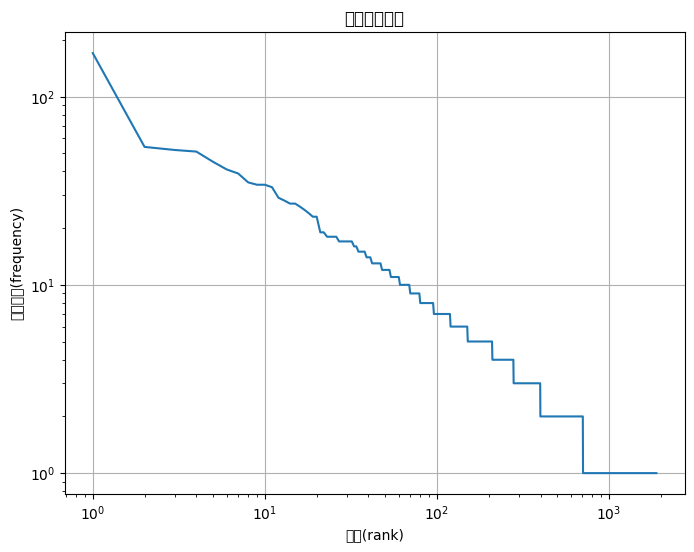

In [16]:
import matplotlib.pyplot as plt
from collections import Counter
import json
import gzip

freq_rank=sorted(word_counts.values(),reverse=True)     #.values() で出現回数だけを取り出す。sorted(..., reverse=True) で大きい順に並べ替える。

ranks=range(1,len(freq_rank)+1)     #横軸：順位(1から単語数までの連番)
freqs=freq_rank                     #縦軸：出現回数

plt.figure(figsize=(8,6))
plt.plot(ranks,freqs)
plt.xscale('log')       #x軸を対数スケールにする
plt.yscale('log')
plt.xlabel('順位(rank)')
plt.ylabel('出現頻度(frequency)')
plt.title('ジップの法則')
plt.grid(True)
plt.show()

ジップの法則とは「1番よく出る単語は2番目の約2倍、3番目の約3倍の頻度で出る」という自然言語の普遍的な性質のこと。